# AgriBot — Fine-tuning FLAN-T5 for Farming Q&A

**SDG 2: Zero Hunger | NLP Project**

This notebook fine-tunes `google/flan-t5-small` on an agricultural Q&A dataset to build a simple farming advisory chatbot. Run each cell in order.

**Pipeline overview:**
1. Install & import
2. Load & explore data
3. Preprocess & tokenize
4. Fine-tune with HuggingFace Trainer
5. Evaluate (BLEU + ROUGE)
6. Interactive inference

> **Platform:** Designed for Kaggle Notebooks or Google Colab (free T4 GPU). Expected total runtime: ~30–45 min.

---
## Section 1 — Install & Import

Install required libraries. On Kaggle, `transformers` and `datasets` are pre-installed — the `evaluate` library may need installing.

In [1]:
# Install libraries (safe to re-run — will skip if already installed)
!pip install -q transformers datasets evaluate rouge_score sentencepiece accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    GenerationConfig,
)
import evaluate

# Check GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU found. Training will be very slow on CPU.")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


---
## Section 2 — Load & Explore Data

Our dataset is a CSV with three columns: `Crop`, `Question`, `Answer`. We load it directly from a string here so the notebook is self-contained — in practice, upload your CSV and use `pd.read_csv('your_file.csv')`.

In [4]:
import io


df = pd.read_csv('/kaggle/input/datasets/faizyah/agroqa/AgroQA Dataset.csv')
df.columns = df.columns.str.strip()
df = df.dropna()

print(f"Total rows: {len(df)}")
df.head(8)

Total rows: 3043


,Crop,Question,Answer
0,maize,"Apart from hand weeding, what other method use...",Machinery weeders are available
1,beans,"Apart from insecticide, what other method used...",Use resistant verities and increase on water a...
2,maize,Apart from sun drying which other method used ...,Use tarpaulins or cemented floor free from dust
3,cassava,"Apart from sun drying, what other method can I...",Solar driers
4,beans,As a farmer when should I harvest beans.,When the beans pods are yellowish green or dry...
5,general,As a farmer which method is good to prevent so...,Farmers can terrace their gardens or mulch the...
6,general,"As a farmer, How can I control pest",Spray some pests and if possible use resistant...
7,general,"As a farmer, how can I control pig weeds in th...",Weed when they are young and you can also spra...


In [5]:
# Quick data exploration
print("=== Crop distribution ===")
print(df['Crop'].value_counts())

print("\n=== Question length stats ===")
df['q_len'] = df['Question'].str.split().str.len()
df['a_len'] = df['Answer'].str.split().str.len()
print(df[['q_len', 'a_len']].describe().round(1))

print("\n=== Sample Q&A ===")
for _, row in df.sample(3, random_state=42).iterrows():
    print(f"  Crop : {row['Crop']}")
    print(f"  Q    : {row['Question']}")
    print(f"  A    : {row['Answer']}")
    print()

=== Crop distribution ===
Crop
cassava    1073
maize       724
beans       685
general     561
Name: count, dtype: int64

=== Question length stats ===
        q_len   a_len
count  3043.0  3043.0
mean      8.2     7.2
std       2.5     5.4
min       2.0     0.0
25%       7.0     3.0
50%       8.0     6.0
75%      10.0    10.0
max      24.0    37.0

=== Sample Q&A ===
  Crop : maize
  Q    : How does wind erosion affect maize plants in my garden ?
  A    : Leads to loss of nutrients

  Crop : maize
  Q    : which variety of maize is high yielding?
  A    : Longe 10 and Nnalongo

  Crop : general
  Q    : How can I improve the fertility of soil
  A    : Applying organic mature/ planting trees



---
## Section 3 — Preprocess & Tokenize

FLAN-T5 is an instruction-following model. It expects a task prefix in the input, e.g.:

```
input  → "answer farming question: How can I control bean rust?"
output → "Use resistant varieties"
```

We also include the `Crop` field in the prompt as context. Then we split into train/validation/test and tokenize.

In [6]:
# Build input strings with task prefix + crop context
def build_input(row):
    crop = row['Crop'].strip().lower()
    question = row['Question'].strip()
    if crop == 'general':
        return f"answer farming question: {question}"
    else:
        return f"answer farming question about {crop}: {question}"

df['input_text']  = df.apply(build_input, axis=1)
df['target_text'] = df['Answer'].str.strip()

# Preview formatted examples
print("Formatted examples:")
for _, row in df.head(3).iterrows():
    print(f"  INPUT : {row['input_text']}")
    print(f"  TARGET: {row['target_text']}")
    print()

Formatted examples:
  INPUT : answer farming question about maize: Apart from hand weeding, what other method used to weed maize
  TARGET: Machinery weeders are available

  INPUT : answer farming question about beans: Apart from insecticide, what other method used to control bean weevils?
  TARGET: Use resistant verities and increase on water availability for crop vigor

  INPUT : answer farming question about maize: Apart from sun drying which other method used for drying maize
  TARGET: Use tarpaulins or cemented floor free from dust



In [7]:
from sklearn.model_selection import train_test_split

# 70% train, 15% val, 15% test
# With a small dataset like this, we keep test small to have more training data
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df,   test_df  = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train : {len(train_df)} rows")
print(f"Val   : {len(val_df)} rows")
print(f"Test  : {len(test_df)} rows")

# Convert to HuggingFace Dataset format
cols = ['input_text', 'target_text']
dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df[cols].reset_index(drop=True)),
    'val':   Dataset.from_pandas(val_df[cols].reset_index(drop=True)),
    'test':  Dataset.from_pandas(test_df[cols].reset_index(drop=True)),
})
print("\nDataset:", dataset)

Train : 2130 rows
Val   : 456 rows
Test  : 457 rows

Dataset: DatasetDict({
    train: Dataset({
        features: ['input_text', 'target_text'],
        num_rows: 2130
    })
    val: Dataset({
        features: ['input_text', 'target_text'],
        num_rows: 456
    })
    test: Dataset({
        features: ['input_text', 'target_text'],
        num_rows: 457
    })
})


In [8]:
MODEL_NAME  = "google/flan-t5-small"   # 60M params, free-GPU friendly
MAX_INPUT   = 128                        # max tokens for question
MAX_TARGET  = 64                         # max tokens for answer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer vocab size: {tokenizer.vocab_size:,}")

def tokenize(batch):
    # Tokenize inputs
    model_inputs = tokenizer(
        batch['input_text'],
        max_length=MAX_INPUT,
        padding='max_length',
        truncation=True,
    )
    # Tokenize targets — use tokenizer as context manager to set as_target_tokenizer
    labels = tokenizer(
        text_target=batch['target_text'],
        max_length=MAX_TARGET,
        padding='max_length',
        truncation=True,
    )
    # Replace padding token id in labels with -100 so loss ignores them
    labels['input_ids'] = [
        [(tok if tok != tokenizer.pad_token_id else -100) for tok in label]
        for label in labels['input_ids']
    ]
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

tokenized = dataset.map(tokenize, batched=True, remove_columns=['input_text', 'target_text'])
tokenized.set_format('torch')

print("\nTokenized dataset:")
print(tokenized)
print("\nSample keys:", list(tokenized['train'][0].keys()))

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Tokenizer vocab size: 32,100


Map:   0%|          | 0/2130 [00:00<?, ? examples/s]

Map:   0%|          | 0/456 [00:00<?, ? examples/s]

Map:   0%|          | 0/457 [00:00<?, ? examples/s]


Tokenized dataset:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2130
    })
    val: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 456
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 457
    })
})

Sample keys: ['input_ids', 'attention_mask', 'labels']


---
## Section 4 — Fine-tune with HuggingFace Trainer

We load FLAN-T5-small and fine-tune using `Seq2SeqTrainer`. Key hyperparameters:
- **learning_rate**: `3e-4` — standard for T5 fine-tuning
- **epochs**: 10 — small dataset benefits from more passes
- **batch_size**: 8 — fits comfortably in 16GB VRAM
- **predict_with_generate**: must be `True` for seq2seq evaluation

In [9]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Total parameters    : 76,961,152
Trainable parameters: 76,961,152


In [11]:
OUTPUT_DIR = "./agribot_model"

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,

    # Training schedule
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=3e-4,
    weight_decay=0.01,
    warmup_steps=10,

    # Evaluation
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',

    # Generation (required for seq2seq eval)
    predict_with_generate=True,
    generation_max_length=MAX_TARGET,

    # Logging
    logging_steps=5,
    report_to='none',      # disable wandb/tensorboard

    # Memory
    fp16=(device == 'cuda'),   # half-precision on GPU — halves memory usage
)

# Data collator pads batches dynamically (more efficient than padding all to MAX_INPUT)
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
)

print("Training arguments set.")

Training arguments set.


In [15]:
# Load ROUGE metric — used for sequence generation evaluation
rouge = evaluate.load('rouge')

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Clip predictions to valid token id range before decoding
    # -100 can sneak in from padding — this prevents the OverflowError
    predictions = np.clip(predictions, 0, tokenizer.vocab_size - 1)

    decoded_preds  = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels         = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )
    return {k: round(v, 4) for k, v in result.items()}

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['val'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer ready. Starting training...")

Trainer ready. Starting training...


In [16]:
# ── TRAIN ─────────────────────────────────────────────────────────────────
# Expected time on Kaggle T4 GPU: ~15–30 minutes
# You will see loss decreasing each epoch — that's the model learning

train_result = trainer.train()
print("\nTraining complete!")
print(f"Total training time : {train_result.metrics['train_runtime']:.0f} seconds")
print(f"Samples per second  : {train_result.metrics['train_samples_per_second']:.1f}")

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,8.726132,4.128792,0.096500,0.005400,0.092100,0.092900
2,7.695357,3.799281,0.124800,0.014500,0.118000,0.118700
3,7.040302,3.584448,0.132500,0.024000,0.128100,0.128900
4,6.231872,3.430635,0.135700,0.023500,0.130100,0.131100
5,6.079329,3.324951,0.135100,0.022400,0.128100,0.128900
6,6.221273,3.230834,0.146100,0.024800,0.140000,0.140400
7,5.466424,3.174982,0.155600,0.033500,0.148200,0.148300
8,5.737359,3.142287,0.157000,0.030700,0.150800,0.150300
9,5.578968,3.113796,0.166600,0.033300,0.158200,0.158800
10,4.875383,3.109941,0.163000,0.031400,0.155200,0.155900


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].



Training complete!
Total training time : 525 seconds
Samples per second  : 40.6


In [24]:
# Save the fine-tuned model and tokenizer
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to: {OUTPUT_DIR}")
print(f"Files: {os.listdir(OUTPUT_DIR)}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./agribot_model
Files: ['checkpoint-402', 'tokenizer_config.json', 'checkpoint-268', 'tokenizer.json', 'checkpoint-1206', 'generation_config.json', 'config.json', 'checkpoint-670', 'model.safetensors', 'checkpoint-804', 'checkpoint-1072', 'checkpoint-536', 'checkpoint-1340', 'checkpoint-938', 'checkpoint-134']


---
## Section 5 — Evaluation

We evaluate on the held-out **test set** using:
- **ROUGE-1 / ROUGE-2 / ROUGE-L**: measures n-gram overlap between predicted and reference answers. Higher = better.
- **BLEU**: similar idea, precision-focused. Common for generation tasks.
- **Qualitative inspection**: look at actual predictions vs. ground truth.

In [18]:
# Run evaluation on test set
test_results = trainer.predict(tokenized['test'])

# Clip predictions to valid token range before decoding
predictions = np.clip(test_results.predictions, 0, tokenizer.vocab_size - 1)

preds  = tokenizer.batch_decode(predictions, skip_special_tokens=True)
labels = np.where(test_results.label_ids != -100, test_results.label_ids, tokenizer.pad_token_id)
refs   = tokenizer.batch_decode(labels, skip_special_tokens=True)

preds = [p.strip() for p in preds]
refs  = [r.strip() for r in refs]

# ROUGE scores
rouge_scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
print("=== ROUGE scores (test set) ===")
for k, v in rouge_scores.items():
    print(f"  {k:10s}: {v:.4f}")

# BLEU score
bleu = evaluate.load('bleu')
bleu_score = bleu.compute(
    predictions=preds,
    references=[[r] for r in refs]
)
print(f"\n=== BLEU score (test set) ===")
print(f"  bleu: {bleu_score['bleu']:.4f}")

=== ROUGE scores (test set) ===
  rouge1    : 0.1722
  rouge2    : 0.0481
  rougeL    : 0.1671
  rougeLsum : 0.1687



=== BLEU score (test set) ===
  bleu: 0.0339


In [19]:
# Qualitative inspection — compare predictions vs ground truth
print("=== Prediction samples (test set) ===")
print("-" * 70)

test_questions = test_df['input_text'].tolist()

for i in range(min(8, len(preds))):
    print(f"Q   : {test_questions[i]}")
    print(f"Pred: {preds[i]}")
    print(f"Ref : {refs[i]}")
    print("-" * 70)

=== Prediction samples (test set) ===
----------------------------------------------------------------------
Q   : answer farming question: what is the importance of early planting
Pred: Use good cropping practices
Ref : Helps in increasing yield
----------------------------------------------------------------------
Q   : answer farming question about maize: how can I stop caterpillars from eating the maize seed?
Pred: Use pesticides and good crop management practices
Ref : Spray with chemicals
----------------------------------------------------------------------
Q   : answer farming question about beans: why are the bean seeds so small?
Pred: It is a good place to plant and use the seeds
Ref : It may be due to stunted growth of beans which leads to small seeds or diseases
----------------------------------------------------------------------
Q   : answer farming question about beans: what is the spacing for Nase14 cassava?
Pred: 1X1 cm
Ref : 1meter X 1meter
--------------------------

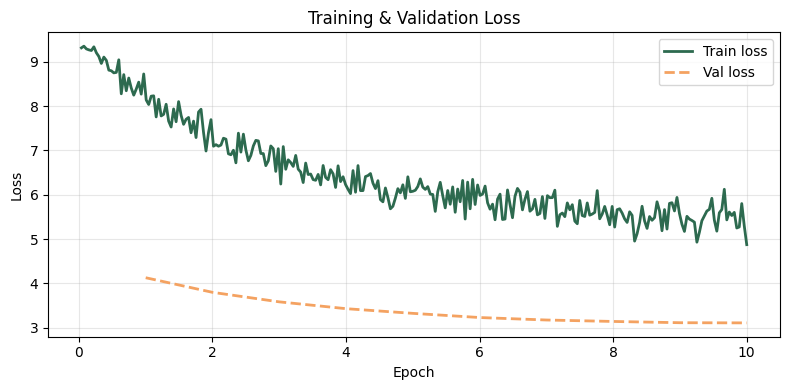

Training curve saved as training_curve.png


In [20]:
import matplotlib.pyplot as plt

# Extract training loss history from trainer logs
log_history = trainer.state.log_history

train_losses = [(x['epoch'], x['loss'])       for x in log_history if 'loss' in x]
eval_losses  = [(x['epoch'], x['eval_loss'])  for x in log_history if 'eval_loss' in x]

fig, ax = plt.subplots(figsize=(8, 4))

if train_losses:
    t_epochs, t_vals = zip(*train_losses)
    ax.plot(t_epochs, t_vals, label='Train loss', color='#2D6A4F', linewidth=2)

if eval_losses:
    e_epochs, e_vals = zip(*eval_losses)
    ax.plot(e_epochs, e_vals, label='Val loss',   color='#F4A261', linewidth=2, linestyle='--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curve.png', dpi=120)
plt.show()
print("Training curve saved as training_curve.png")

---
## Section 6 — Interactive Inference

Load the saved model and ask it farming questions directly. This simulates the chatbot experience.

In [25]:
# Load the saved fine-tuned model
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

ft_tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)
ft_model     = AutoModelForSeq2SeqLM.from_pretrained(OUTPUT_DIR).to(device)
ft_model.eval()
print("Fine-tuned model loaded.")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Fine-tuned model loaded.


In [26]:
def ask_agribot(question: str, crop: str = 'general', max_new_tokens: int = 64) -> str:
    """
    Ask AgriBot a farming question.

    Args:
        question: The farming question in plain English.
        crop    : Crop context ('general', 'maize', 'beans', 'cassava', ...).
        max_new_tokens: Max length of generated answer.

    Returns:
        Generated answer string.
    """
    crop = crop.strip().lower()
    if crop == 'general':
        prompt = f"answer farming question: {question}"
    else:
        prompt = f"answer farming question about {crop}: {question}"

    inputs = ft_tokenizer(
        prompt,
        return_tensors='pt',
        max_length=MAX_INPUT,
        truncation=True,
    ).to(device)

    with torch.no_grad():
        outputs = ft_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,           # beam search for better quality
            early_stopping=True,
            no_repeat_ngram_size=2,
        )

    return ft_tokenizer.decode(outputs[0], skip_special_tokens=True)

print("ask_agribot() function ready.")

ask_agribot() function ready.


In [27]:
# ── Try it out ─────────────────────────────────────────────────────────────
test_cases = [
    ("How can I control bean rust?",                       "beans"),
    ("When should I harvest cassava?",                     "cassava"),
    ("What is the best time to water my crops?",           "general"),
    ("How do I apply fertilizer to my maize garden?",     "maize"),
    ("How can I prevent soil erosion on my farm?",         "general"),
]

print("=" * 65)
print("  AgriBot — Farming Advisory Chatbot")
print("=" * 65)
for question, crop in test_cases:
    answer = ask_agribot(question, crop)
    print(f"\n[{crop.upper()}]")
    print(f"  Q: {question}")
    print(f"  A: {answer}")
print("\n" + "=" * 65)

  AgriBot — Farming Advisory Chatbot

[BEANS]
  Q: How can I control bean rust?
  A: Use good cropping practices

[CASSAVA]
  Q: When should I harvest cassava?
  A: At the beginning of the season

[GENERAL]
  Q: What is the best time to water my crops?
  A: It is a good time to use water

[MAIZE]
  Q: How do I apply fertilizer to my maize garden?
  A: Use a fertilizers in the garden

[GENERAL]
  Q: How can I prevent soil erosion on my farm?
  A: Use pesticides and good crop management practices



In [ ]:
# ── Interactive loop — type your own questions ──────────────────────────────
# Run this cell and type questions. Type 'quit' to stop.

print("AgriBot is ready! Type 'quit' to stop.")
print("Format: crop | question  (e.g. 'maize | How do I prevent stalk rot?')")
print("-" * 55)

while True:
    try:
        user_input = input("You: ").strip()
    except EOFError:
        break

    if not user_input or user_input.lower() == 'quit':
        print("Goodbye!")
        break

    if '|' in user_input:
        parts = user_input.split('|', 1)
        crop_in = parts[0].strip()
        q_in    = parts[1].strip()
    else:
        crop_in = 'general'
        q_in    = user_input

    answer = ask_agribot(q_in, crop_in)
    print(f"AgriBot [{crop_in}]: {answer}\n")

AgriBot is ready! Type 'quit' to stop.
Format: crop | question  (e.g. 'maize | How do I prevent stalk rot?')
-------------------------------------------------------


You:  maize | How do I prevent stalk rot?


AgriBot [maize]: Use good cropping practices



---
## Summary

| Step | What we did |
|------|-------------|
| Data | Loaded CSV with Crop/Question/Answer columns |
| Format | Added task prefix `answer farming question about {crop}:` |
| Split | 70 / 15 / 15 train / val / test |
| Model | `google/flan-t5-small` (60M params) |
| Training | 10 epochs, lr=3e-4, batch=8, fp16 on GPU |
| Evaluation | ROUGE-1/2/L + BLEU on test set + qualitative inspection |
| Inference | `ask_agribot(question, crop)` with beam search |

**Next steps if you want to improve:**
- Add more Q&A pairs (target 500+) for better generalization
- Try `google/flan-t5-base` (250M) for higher quality answers
- Add a Gradio UI for a live demo (`pip install gradio`)
- Compute human evaluation scores (relevance + accuracy 1–5)